# Contrafactuais — um passo a passo no modelo COVID

O mesmo modelo dos módulos 00–03, e a pergunta invertida: em vez de "o
que pesou nesta predição?", **"qual é a menor mudança que muda a
predição?"** (Molnar, cap. 15; Wachter et al., 2018). A inversão muda o
papel das cercas: até aqui, paciente impossível era diagnóstico de
método doente; aqui a impossibilidade vira **restrição de busca** — e
ganha uma irmã que a `gate_impossible` não vê: a acionabilidade.

**O que você deve saber fazer ao final**

1. Formular a busca contrafactual como enumeração sobre movimentos
   declarados — e dizer quando exaustão vence busca genética.
2. Nomear os cinco critérios do cap. 15 (validade, proximidade,
   sparsidade, plausibilidade, diversidade) e apontar como cada um é
   operacionalizado — e medido — neste módulo.
3. Reconhecer o efeito Rashomon numa lista de contrafactuais válidos, e
   explicar por que o mais próximo pode ser inútil e o mais eficaz,
   absurdo.
4. Reportar honestamente o caso em que **não há** contrafactual — e por
   que essa é uma resposta do método, não uma falha dele.

Tudo que este notebook afirma é impresso por uma célula dele ou do
companheiro `cf_internals.ipynb` — que refaz a busca sem recorte, decompõe
a invalidez por cerca e testa a sensibilidade do limiar. Módulo novo:
não há era BCW.

In [1]:
%pip install -q xgboost scikit-learn matplotlib numpy pandas pyarrow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pathlib
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
RANDOM_STATE = 42

REPO = pathlib.Path.cwd()
while REPO != REPO.parent and not (REPO / "tools" / "srag_model.py").exists():
    REPO = REPO.parent
if not (REPO / "tools" / "srag_model.py").exists():
    import tempfile
    REPO = pathlib.Path(tempfile.gettempdir()) / "interpretable-ml-lectures"
    if not REPO.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/wbendinelli/interpretable-ml-lectures.git",
                        str(REPO)], check=True)
sys.path.insert(0, str(REPO / "tools"))
import srag_model as M

FIGDIR = pathlib.Path("figures_generated")
FIGDIR.mkdir(exist_ok=True)

g = M.load_gold(REPO / "modules/00-dataset/gold/gold_covid_obito_sample.parquet")
xgb, _logit = M.fit_models(g)

# o paciente deste módulo, POR REGRA: contrafactual pede alguém com o que
# perder — p mais próximo de 0,8 no teste, empate por gold_id
teste = g[g["split"] == "test"].reset_index(drop=True)
p_teste = M.predict_proba(xgb, teste)
ordem = np.lexsort((teste["gold_id"].to_numpy(), np.abs(p_teste - 0.8)))
alto = teste.iloc[ordem[0]].copy()
alto["p_obito"] = float(p_teste[ordem[0]])


def fmt(v):
    return f"{float(v):.1f}" if isinstance(v, (int, float, np.floating)) else str(v)


print(f"paciente de alto risco: gold_id {int(alto['gold_id'])}  "
      f"p(óbito) {alto['p_obito']:.4f}")
print(f"  idade {alto['idade_anos']:.0f} | doses {int(alto['n_doses_antes_do_sintoma'])} | "
      f"meses desde mar/2020 {alto['meses_desde_mar2020']:.1f} | "
      f"fator de risco declarado: {bool(alto['fator_risc_portao'])}")
comorbs = [c for c in M.CATEGORICAS[5:18] if str(alto[c]) == "sim"]
sintomas = [c for c in M.CATEGORICAS[18:31] if str(alto[c]) == "sim"]
print(f"  comorbidades sim: {comorbs}")
print(f"  sintomas sim: {sintomas}")

paciente de alto risco: gold_id 1267430  p(óbito) 0.8043
  idade 81 | doses 3 | meses desde mar/2020 46.3 | fator de risco declarado: True
  comorbidades sim: ['pneumopati', 'imunodepre', 'out_morbi']
  sintomas sim: ['febre', 'tosse', 'dispneia', 'desc_resp', 'saturacao', 'vomito', 'fadiga']


## O que o método é

Do cap. 15, a definição em uma frase: *"A counterfactual explanation of
a prediction describes the smallest change to the feature values that
changes the prediction to a predefined output."* É o único método do
curso cuja saída é um **paciente hipotético**, não um número por feature
— e por isso é o método em que as cercas do módulo 00 param de ser
crítica e viram parte da resposta.

Wachter et al. (2018) formulam como otimização:

$$L(x') = \lambda \cdot \big(f(x') - y'\big)^2 + d(x, x')$$

| símbolo | o que é | aqui |
|---|---|---|
| $x'$ | o candidato a contrafactual | uma linha do Ouro com 1–2 campos trocados |
| $y'$ | a saída desejada | $p < 0{,}5$ (sobreviver, aos olhos do modelo) |
| $f(x') - y'$ | o termo de **validade** | a distância ao alvo, no eixo y do passo 2 |
| $d(x, x')$ | o termo de **proximidade** | Gower nas 40 features (a métrica que o cap. 15 recomenda para dado misto) |
| $\lambda$ | o câmbio entre os dois | **não precisamos dele** — ver abaixo |

**A escolha de configuração deste módulo, declarada:** nada de descida
de gradiente nem algoritmo genético. O espaço de busca cabe na memória
(113 mudanças simples, 6.129 pares), então a fronteira inteira da perda
de Wachter é **enumerada** — todo candidato avaliado, determinístico,
zero sementes — e o λ vira desnecessário: em vez de escolher um ponto da
troca validade×proximidade, mostramos a troca inteira (passo 2). DiCE
(Mothilal et al., 2020) não roda no stack pinado (numpy 2.x; decisão no
PR do pin); Dandl et al. (2020) resolvem com NSGA-II o que aqui se
resolve por exaustão — é o que faríamos se o espaço não coubesse.

Os **cinco critérios** do capítulo, e onde cada um mora neste notebook:

| critério (cap. 15) | operacionalização aqui |
|---|---|
| validade | cruzar $p = 0{,}5$ |
| proximidade | Gower ao paciente (passo 2 e tabelas do §6) |
| sparsidade | profundidade da busca: 1–2 mudanças por construção |
| plausibilidade | `gate_impossible` — a cerca derivável do módulo 00 |
| diversidade | o efeito Rashomon, medido no §4 |

E um sexto que o capítulo não formaliza e este módulo acrescenta:
**acionabilidade** (§5) — estar ao alcance de quem recebe a explicação.

## O paciente, e por que ele

Regra declarada: **p mais próximo de 0,8 no teste**, empate por
`gold_id` — não o paciente-regra dos módulos 01–03. O motivo é
geométrico: um contrafactual precisa de alguém **com o que perder**.
Para o paciente em $p = 0{,}5$, qualquer sopro cruza o limiar e toda a
busca degenera em trivialidade; para o de 0,8, cruzar exige mudanças
com conteúdo — e a pergunta "quais?" vira interessante.

Saiu um senhor de 81 anos, 3 doses, imunodeprimido e pneumopata, início
em 2024. Nada disso é propriedade dos dados: é uma regra de legibilidade,
dita como tal.

## §1 — O espaço de busca, declarado

Movimentos por feature: idade em passos de 10, doses 0–6, meses em
passos de 6, booleanas nos dois valores, categóricas em todos os níveis.
`semana_epi` fica fora — é atrelada a `meses_desde_mar2020`, e mover uma
sem a outra fabricaria um calendário que não existe (a lição do módulo
03 aplicada ao **desenho** da busca, antes de medir).

**O que olhar na contagem:** o espaço é dominado por demografia,
comorbidade e sintoma — 86 dos 113 movimentos são coisas que ninguém
decide ter. A busca corre **livre** primeiro, para ver o que o método
*quer*; os filtros entram depois, um de cada vez, com contagem.

In [3]:
MOVES = {}
MOVES["idade_anos"] = [float(v) for v in range(0, 101, 10)]
MOVES["n_doses_antes_do_sintoma"] = [float(v) for v in range(0, 7)]
MOVES["meses_desde_mar2020"] = [float(v) for v in range(0, 59, 6)]
for c in M.BOOLEANAS:
    MOVES[c] = [False, True]
for c in M.CATEGORICAS:
    MOVES[c] = list(g[c].cat.categories)
# semana_epi fica fora: é atrelada a meses_desde_mar2020 — mover uma sem a
# outra fabricaria um calendário que não existe

GRUPO = {}
for c in M.CATEGORICAS[:5]:
    GRUPO[c] = "demografia"
for c in M.CATEGORICAS[5:18]:
    GRUPO[c] = "comorbidade"
for c in M.CATEGORICAS[18:31]:
    GRUPO[c] = "sintoma"
for c in M.CATEGORICAS[31:34]:
    GRUPO[c] = "contexto"
GRUPO.update({"idade_anos": "demografia", "meses_desde_mar2020": "tempo",
              "n_doses_antes_do_sintoma": "dose", "vacina_covid_declarada": "dose",
              "coinfeccao_outro_virus": "comorbidade"})


def candidatos_1(pac):
    out = []
    for c, vals in MOVES.items():
        for v in vals:
            if c in M.CATEGORICAS:
                if str(v) == str(pac[c]):
                    continue
            elif float(v) == float(pac[c]):
                continue
            out.append((c, v))
    return out


def aplicar(pac, lista_de_mudancas):
    """cada item é uma lista [(coluna, valor), ...]; devolve um frame."""
    linhas = []
    modelo_linha = {c: pac[c] for c in g.columns}
    for muds in lista_de_mudancas:
        linha = dict(modelo_linha)
        for c, v in muds:
            linha[c] = v
        linhas.append(linha)
    df = pd.DataFrame(linhas)
    return df.astype(g.dtypes)


c1 = candidatos_1(alto)
print(f"movimentos simples possíveis para este paciente: {len(c1)}")
n_grupos = pd.Series([GRUPO[c] for c, _ in c1]).value_counts()
print(n_grupos.to_string())

movimentos simples possíveis para este paciente: 113
demografia     33
comorbidade    27
sintoma        26
tempo          10
contexto       10
dose            7


## §2 — Profundidade 1: o que a busca livre quer

Uma mudança por vez, todas avaliadas num lote só.

**O que olhar na figura:** as cores. A melhor mudança do mundo, segundo
o modelo, é `idade → 10` — "rejuvenesça 71 anos" (laranja, demografia).
As seguintes apagam sintomas (verde) — que são consequência da doença,
não alavanca — e trocam escolaridade/raça por `desconhecido`: o modelo
usando qualidade de documentação, a armadilha que o módulo 00 mediu.
Repare também no que quase **não** aparece: vermelho de cerca. Quem
parte de um paciente real e muda um campo fabrica pouca ficção (3,5%) —
compare com os 30,6% do LIME; a régua é a mesma, o método é que muda.

as 10 mudanças simples que mais derrubam a predição:
  idade_anos -> 10.0: p 0.804 -> 0.480 (demografia)
  idade_anos -> 0.0: p 0.804 -> 0.547 (demografia)
  saturacao -> nao: p 0.804 -> 0.573 (sintoma)
  dispneia -> nao: p 0.804 -> 0.581 (sintoma)
  saturacao -> desconhecido: p 0.804 -> 0.605 (sintoma)
  cs_raca -> desconhecido: p 0.804 -> 0.611 (demografia)
  cs_escol_n -> desconhecido: p 0.804 -> 0.661 (demografia)
  cs_escol_n -> nao_se_aplica: p 0.804 -> 0.663 (demografia)
  cs_escol_n -> fundamental_2: p 0.804 -> 0.676 (demografia)
  nosocomial -> desconhecido: p 0.804 -> 0.678 (contexto)

inválidos pela gate_impossible: 3.5% dos 113
mudanças simples que cruzam 0,5 e passam na cerca: 1


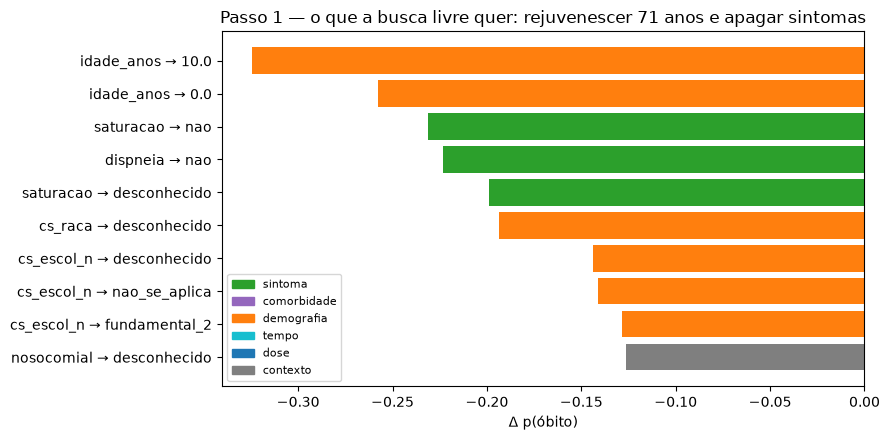

In [4]:
f1 = aplicar(alto, [[m] for m in c1])
p1 = M.predict_proba(xgb, f1)
delta = p1 - alto["p_obito"]
invalido1 = M.gate_impossible(f1).to_numpy()

melhores = np.argsort(delta)[:10]
print("as 10 mudanças simples que mais derrubam a predição:")
for i in melhores:
    c, v = c1[i]
    marca = "  [INVÁLIDO pela cerca]" if invalido1[i] else ""
    print(f"  {c} -> {fmt(v)}: p {alto['p_obito']:.3f} -> {p1[i]:.3f} ({GRUPO[c]}){marca}")
cruzam = ((p1 < 0.5) & ~invalido1).sum()
print(f"\ninválidos pela gate_impossible: {100 * invalido1.mean():.1f}% dos {len(c1)}")
print(f"mudanças simples que cruzam 0,5 e passam na cerca: {cruzam}")

CORES = {"sintoma": "tab:green", "comorbidade": "tab:purple",
         "demografia": "tab:orange", "tempo": "tab:cyan", "dose": "tab:blue",
         "contexto": "tab:gray"}
fig, ax = plt.subplots(figsize=(9, 4.5))
nomes = [f"{c1[i][0]} → {fmt(c1[i][1])}" for i in melhores][::-1]
vals = [delta[i] for i in melhores][::-1]
cores = [CORES[GRUPO[c1[i][0]]] for i in melhores][::-1]
ax.barh(nomes, vals, color=cores)
ax.set_xlabel("Δ p(óbito)")
ax.set_title("Passo 1 — o que a busca livre quer: rejuvenescer 71 anos e apagar sintomas")
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in CORES.values()]
ax.legend(handles, CORES.keys(), loc="lower left", fontsize=8)
fig.tight_layout()
fig.savefig(FIGDIR / "cf_passo_1_busca_livre.png", dpi=150, bbox_inches="tight")
plt.show()

## §3 — Profundidade 2: a perda de Wachter, enumerada

Pares sobre os 60 melhores movimentos (o espaço completo, sem recorte,
está nos internals §1 — mesmo ótimo). O gráfico deste passo é a função
de perda de Wachter **vista por inteiro**: eixo x = proximidade (Gower),
eixo y = validade (p do candidato); cada ponto é um candidato avaliado.
Escolher λ é escolher um ponto desta nuvem; nós mostramos a nuvem.

**O que olhar:** o canto que interessa — perto do paciente E abaixo de
0,5 — e quem mora nele. Os melhores candidatos "válidos" pedem que o
senhor de 81 anos seja uma criança sem imunodepressão, ou uma gestante
de terceiro trimestre. São pacientes que **podem existir** (a
`gate_impossible` responde "isso existe?"); não são alcançáveis a partir
de quem ele é (ela não foi desenhada para responder "dá para chegar lá?").
Por que "curar" a imunodepressão passa na cerca é medido nos internals
§3: o portão do funil é unidirecional no dado real.

pares avaliados: 1706 | inválidos: 3.4% | cruzam 0,5 válidos: 151

os 5 melhores contrafactuais 'válidos' — leia com atenção:
  idade_anos → 10.0 + imunodepre → nao: p -> 0.182
  idade_anos → 10.0 + imunodepre → desconhecido: p -> 0.188
  idade_anos → 10.0 + cs_gestant → 3_trimestre: p -> 0.203
  idade_anos → 10.0 + dispneia → nao: p -> 0.221
  idade_anos → 10.0 + saturacao → nao: p -> 0.222


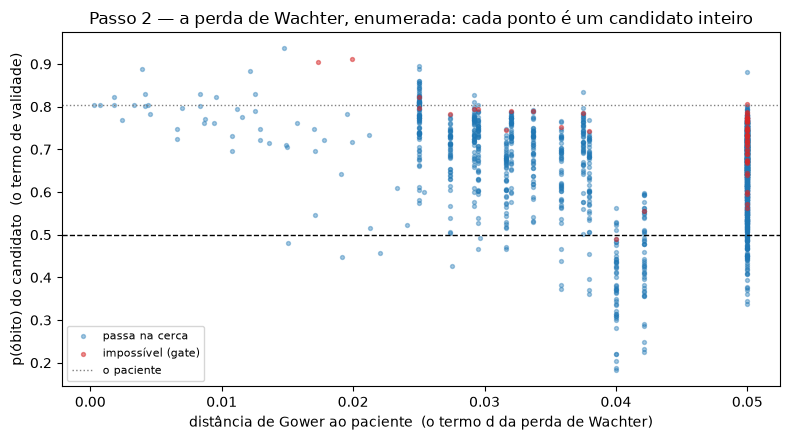

In [5]:
top60 = list(np.argsort(delta)[:60])
pares = [[c1[i], c1[j]] for a, i in enumerate(top60)
         for j in top60[a + 1:] if c1[i][0] != c1[j][0]]
f2 = aplicar(alto, pares)
p2 = M.predict_proba(xgb, f2)
invalido2 = M.gate_impossible(f2).to_numpy()
ok2 = (p2 < 0.5) & ~invalido2
print(f"pares avaliados: {len(pares)} | inválidos: {100 * invalido2.mean():.1f}% | "
      f"cruzam 0,5 válidos: {ok2.sum()}")
print("\nos 5 melhores contrafactuais 'válidos' — leia com atenção:")
mostrados = 0
for i in np.argsort(p2):
    if not ok2[i]:
        continue
    desc = " + ".join(f"{c} → {fmt(v)}" for c, v in pares[i])
    print(f"  {desc}: p -> {p2[i]:.3f}")
    mostrados += 1
    if mostrados >= 5:
        break

NUM_G = list(M.NUMERICAS)
CAT_G = list(M.CATEGORICAS) + list(M.BOOLEANAS)
FAIXAS = {c: float(g[c].max() - g[c].min()) or 1.0 for c in NUM_G}


def gower_par(pac, frame):
    """Gower paciente ↔ cada linha do frame, nas 40 features (par a par —
    a mesma família de métrica do módulo 01, que media ao vizinho real)."""
    d = np.zeros(len(frame))
    for c in NUM_G:
        d += np.abs(frame[c].to_numpy(dtype=float) - float(pac[c])) / FAIXAS[c]
    for c in CAT_G:
        d += (frame[c].astype(str).to_numpy() != str(pac[c])).astype(float)
    return d / (len(NUM_G) + len(CAT_G))


g1, g2 = gower_par(alto, f1), gower_par(alto, f2)
fig, ax = plt.subplots(figsize=(8, 4.5))
todos_p = np.concatenate([p1, p2])
todos_g = np.concatenate([g1, g2])
todos_inv = np.concatenate([invalido1, invalido2])
ax.scatter(todos_g[~todos_inv], todos_p[~todos_inv], s=8, alpha=0.4,
           color="tab:blue", label="passa na cerca")
ax.scatter(todos_g[todos_inv], todos_p[todos_inv], s=8, alpha=0.5,
           color="tab:red", label="impossível (gate)")
ax.axhline(0.5, color="black", lw=1, ls="--")
ax.axhline(alto["p_obito"], color="gray", lw=1, ls=":", label="o paciente")
ax.set_xlabel("distância de Gower ao paciente  (o termo d da perda de Wachter)")
ax.set_ylabel("p(óbito) do candidato  (o termo de validade)")
ax.set_title("Passo 2 — a perda de Wachter, enumerada: cada ponto é um candidato inteiro")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGDIR / "cf_passo_2_fronteira.png", dpi=150, bbox_inches="tight")
plt.show()

## §4 — O efeito Rashomon: três histórias válidas que se contradizem

O cap. 15 avisa: *"For each instance, you will usually find multiple
counterfactual explanations (Rashomon effect)"* — múltiplas explicações
igualmente válidas contando histórias contraditórias sobre como chegar
ao desfecho. Aqui isso não é um risco teórico: são 151 candidatos
válidos cruzando 0,5. A célula escolhe, por regra gulosa, três com
conjuntos de features **disjuntos** — três receitas sem um ingrediente
em comum.

**O que olhar:** cada tabela sozinha parece uma explicação; as três
juntas mostram que "a explicação" não existe — existe um cardápio, e a
escolha de qual servir é de quem explica, não do método. O critério de
**diversidade** do capítulo é exatamente pedir o cardápio de uma vez
(é o que o DiCE otimiza); a resposta honesta continua sendo mostrar que
ele existe.

In [6]:
validos = [i for i in np.argsort(p2) if ok2[i]]
historias = []
for i in validos:
    feats = {c for c, _ in pares[i]}
    if all(feats.isdisjoint(fs) for _, fs in historias):
        historias.append((i, feats))
    if len(historias) == 3:
        break
print(f"3 histórias com features DISJUNTAS, escolhidas dos {int(ok2.sum())} "
      f"contrafactuais válidos (gula por menor p):\n")
for n, (i, _) in enumerate(historias, 1):
    tab = pd.DataFrame(
        [(c, fmt(alto[c]), fmt(v)) for c, v in pares[i]],
        columns=["feature", "paciente", "contrafactual"])
    print(f"história {n}  —  p: {alto['p_obito']:.3f} → {p2[i]:.3f}")
    print(tab.to_string(index=False))
    print()
print("as três são 'válidas', as três contradizem umas às outras sobre o que")
print("importa — vire uma criança sem imunodepressão; apague a saturação baixa")
print("e o registro de raça; conste como gestante de idade ignorada, aos 81.")
print("É o efeito Rashomon do cap. 15: qual história você contaria ao paciente?")

3 histórias com features DISJUNTAS, escolhidas dos 151 contrafactuais válidos (gula por menor p):

história 1  —  p: 0.804 → 0.182
   feature paciente contrafactual
idade_anos     81.4          10.0
imunodepre      sim           nao

história 2  —  p: 0.804 → 0.338
  feature paciente contrafactual
saturacao      sim           nao
  cs_raca    parda  desconhecido

história 3  —  p: 0.804 → 0.395
   feature         paciente              contrafactual
cs_escol_n sem_escolaridade              fundamental_2
cs_gestant    nao_se_aplica idade_gestacional_ignorada

as três são 'válidas', as três contradizem umas às outras sobre o que
importa — vire uma criança sem imunodepressão; apague a saturação baixa
e o registro de raça; conste como gestante de idade ignorada, aos 81.
É o efeito Rashomon do cap. 15: qual história você contaria ao paciente?


## §5 — As alavancas reais

O que uma pessoa (ou uma política de saúde) de fato controla neste
vetor: o histórico vacinal **antes do sintoma** — doses para cima, nunca
para baixo — e a declaração dele. Idade, sexo, comorbidades registradas,
sintomas (consequência, não causa) e o calendário não são alavancas.

**O que olhar:** primeiro o paciente do módulo — subir doses **aumenta**
a p dele (0,829; o módulo 05 §5 explica o porquê dessa atribuição:
grupos priorizados). Depois o teste inteiro: a fração com contrafactual
acionável **cai com o risco** — 43% na banda 0,5–0,6, 3% no 0,7+. Quem
mais precisaria de uma saída é exatamente quem não tem nenhuma ao
alcance. Um método que só sabe dizer "faça X" precisa saber dizer "não
há X".

candidatos acionáveis do paciente de alto risco: 3
  n_doses_antes_do_sintoma → 4.0: p -> 0.829
  n_doses_antes_do_sintoma → 5.0: p -> 0.829
  n_doses_antes_do_sintoma → 6.0: p -> 0.829
algum cruza 0,5? False — o melhor chega a 0.829

pacientes do teste com p >= 0,5: 902 de 16142


com contrafactual ACIONÁVEL que cruza 0,5: 325 (36.0%)
sem nada ao alcance que mude a previsão: 577 (64.0%)

fração com contrafactual acionável, por banda de risco:
             mean  count
banda                   
0,5–0,6  0.431090    624
0,6–0,7  0.250000    216
0,7+     0.032258     62


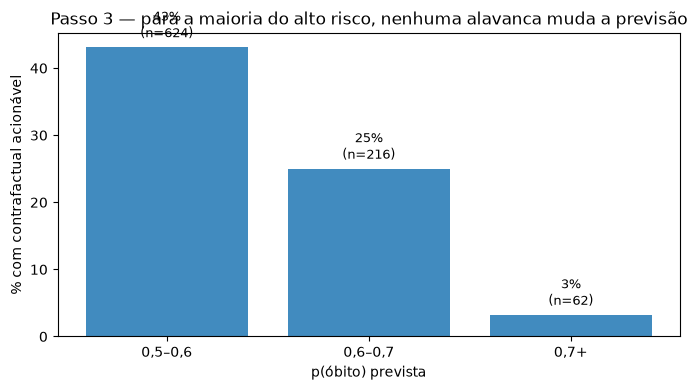

In [7]:
ALAVANCAS = ("n_doses_antes_do_sintoma", "vacina_covid_declarada")


def candidatos_acionaveis(pac):
    """doses só para CIMA (o passado vacinal poderia ter sido maior, nunca
    menor) e a declaração junto; nada mais é alcançável por decisão."""
    d0 = int(pac["n_doses_antes_do_sintoma"])
    cand = [[("n_doses_antes_do_sintoma", float(d))] for d in range(d0 + 1, 7)]
    if not bool(pac["vacina_covid_declarada"]):
        cand += [[("vacina_covid_declarada", True)]]
        cand += [[("n_doses_antes_do_sintoma", float(d)),
                  ("vacina_covid_declarada", True)] for d in range(d0 + 1, 7)]
    return cand


cand_alto = candidatos_acionaveis(alto)
fa = aplicar(alto, cand_alto)
pa = M.predict_proba(xgb, fa)
print(f"candidatos acionáveis do paciente de alto risco: {len(cand_alto)}")
for muds, p in zip(cand_alto, pa):
    desc = " + ".join(f"{c} → {fmt(v)}" for c, v in muds)
    print(f"  {desc}: p -> {p:.3f}")
print(f"algum cruza 0,5? {bool((pa < 0.5).any())} — o melhor chega a {pa.min():.3f}")

# o mesmo teste para TODO paciente de alto risco do split de teste
p_todos = M.predict_proba(xgb, teste)
alto_risco = teste[p_todos >= 0.5].reset_index(drop=True)
print(f"\npacientes do teste com p >= 0,5: {len(alto_risco)} de {len(teste)}")

blocos, indices = [], []
for k in range(len(alto_risco)):
    pac_k = alto_risco.iloc[k]
    cand_k = candidatos_acionaveis(pac_k)
    if cand_k:
        blocos.append(aplicar(pac_k, cand_k))
        indices.extend([k] * len(cand_k))
lote = pd.concat(blocos, ignore_index=True)
p_lote = M.predict_proba(xgb, lote)
flip = pd.Series(p_lote < 0.5).groupby(np.asarray(indices)).any()
com_cf = int(flip.sum())
print(f"com contrafactual ACIONÁVEL que cruza 0,5: {com_cf} "
      f"({100 * com_cf / len(alto_risco):.1f}%)")
print(f"sem nada ao alcance que mude a previsão: {len(alto_risco) - com_cf} "
      f"({100 * (1 - com_cf / len(alto_risco)):.1f}%)")

p_ar = p_todos[p_todos >= 0.5]
bandas = pd.cut(p_ar, [0.5, 0.6, 0.7, 1.0], labels=["0,5–0,6", "0,6–0,7", "0,7+"])
tab = pd.DataFrame({"banda": bandas, "flip": flip.reindex(range(len(alto_risco)),
                                                          fill_value=False).to_numpy()})
resumo = tab.groupby("banda", observed=True)["flip"].agg(["mean", "count"])
print("\nfração com contrafactual acionável, por banda de risco:")
print(resumo.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(resumo.index.astype(str), 100 * resumo["mean"], color="tab:blue", alpha=0.85)
for x, (m, n) in enumerate(zip(resumo["mean"], resumo["count"])):
    ax.text(x, 100 * m + 1.5, f"{100 * m:.0f}%\n(n={n})", ha="center", fontsize=9)
ax.set_ylabel("% com contrafactual acionável")
ax.set_xlabel("p(óbito) prevista")
ax.set_title("Passo 3 — para a maioria do alto risco, nenhuma alavanca muda a previsão")
fig.tight_layout()
fig.savefig(FIGDIR / "cf_passo_3_painel.png", dpi=150, bbox_inches="tight")
plt.show()

## §6 — Três filtros, três tabelas

Os melhores candidatos de cada busca, no formato do capítulo — feature,
valor do paciente, valor do contrafactual — com p, Gower e sparsidade no
cabeçalho.

**O que olhar:** a ordem de Gower. O candidato **mais próximo** de todos
é o acionável (0,0042) — e não cruza; o "melhor" contrafactual válido
está a 0,04 — dez vezes mais longe e absurdo como prescrição. A perda de
Wachter, sozinha, escolheria o absurdo; a proximidade não codifica
mutabilidade, e a plausibilidade (cerca) não codifica alcançabilidade.
*Existir, estar perto, estar ao alcance* — três perguntas, e só a
terceira é sobre o paciente real.

In [8]:
def tabela_cf(titulo, muds, p_novo, frame_1linha):
    print(f"{titulo}  —  p: {alto['p_obito']:.3f} → {p_novo:.3f} | "
          f"Gower {gower_par(alto, frame_1linha)[0]:.4f} | "
          f"{len(muds)} mudança(s)")
    tab = pd.DataFrame([(c, fmt(alto[c]), fmt(v)) for c, v in muds],
                       columns=["feature", "paciente", "contrafactual"])
    print(tab.to_string(index=False))
    print()


melhor_1 = int(np.argmin(p1))
val2 = np.where(ok2)[0]
melhor_2 = int(val2[np.argmin(p2[val2])])
melhor_a = int(np.argmin(pa))

tabela_cf("melhor mudança única (busca livre)", [c1[melhor_1]],
          float(p1[melhor_1]), f1.iloc[[melhor_1]])
tabela_cf("melhor par válido (busca livre)", pares[melhor_2],
          float(p2[melhor_2]), f2.iloc[[melhor_2]])
tabela_cf("melhor acionável (não cruza)", cand_alto[melhor_a],
          float(pa[melhor_a]), fa.iloc[[melhor_a]])

print("o candidato MAIS PRÓXIMO é o acionável — e não cruza; os livres, quase")
print("tão próximos, são absurdos como prescrição. Proximidade não codifica")
print("mutabilidade, e a gate_impossible não codifica acionabilidade. Três")
print("filtros distintos: existir, estar perto, estar ao alcance.")

melhor mudança única (busca livre)  —  p: 0.804 → 0.480 | Gower 0.0150 | 1 mudança(s)
   feature paciente contrafactual
idade_anos     81.4          10.0

melhor par válido (busca livre)  —  p: 0.804 → 0.182 | Gower 0.0400 | 2 mudança(s)
   feature paciente contrafactual
idade_anos     81.4          10.0
imunodepre      sim           nao

melhor acionável (não cruza)  —  p: 0.804 → 0.829 | Gower 0.0042 | 1 mudança(s)
                 feature paciente contrafactual
n_doses_antes_do_sintoma        3           4.0

o candidato MAIS PRÓXIMO é o acionável — e não cruza; os livres, quase
tão próximos, são absurdos como prescrição. Proximidade não codifica
mutabilidade, e a gate_impossible não codifica acionabilidade. Três
filtros distintos: existir, estar perto, estar ao alcance.


## O que o livro diz

Do Molnar, [cap. 15](https://christophm.github.io/interpretable-ml-book/counterfactual.html),
sobre a força do método:

> "The interpretation of counterfactual explanations is very clear (...)
> There are no additional assumptions and no magic in the background."

Verdade — e este módulo mediu o preço da clareza: sem uma lista de
alavancas, o "smallest change" sem mágica devolve *"rejuvenesça 71
anos"*. A ausência de suposições no método empurra as suposições para o
desenho do espaço de busca, onde elas ficam visíveis (e é aí que devem
ficar).

| do capítulo | neste módulo |
|---|---|
| os 5 critérios (validade, proximidade, sparsidade, plausibilidade, diversidade) | operacionalizados um a um — tabela do objetivo, §§2–4 |
| efeito Rashomon como limitação | medido: 151 válidos, 3 histórias disjuntas impressas (§4) |
| Wachter: perda λ·validade + distância | enumerada por inteiro — o passo 2 é a nuvem da perda, sem λ |
| Dandl et al. 2020: NSGA-II multiobjetivo | citado como o caminho quando a enumeração não cabe; aqui cabe (internals §1: ótimo confirmado sem recorte) |
| DiCE (Mothilal et al. 2020): diversidade otimizada | não roda no stack pinado — declarado, com a decisão no PR do pin |

Crédito a quem pertence: a formulação é de Wachter; os critérios e o
Rashomon, do capítulo; a **acionabilidade como sexto filtro medido** — e
o achado de que ela escasseia exatamente onde o risco cresce — é a
contribuição deste módulo.

## Fechamento — a resposta honesta

A pergunta invertida tem três respostas possíveis, e o módulo mediu as
três: *há um contrafactual acionável* (36% do alto risco do teste);
*há contrafactuais válidos, mas nenhum ao seu alcance* (64% — e 97% na
banda de maior risco); *o que a busca livre encontra é absurdo com
carimbo de válido* (o Rashomon do §4).

O que carregar:

1. Exaustão em lote custa milissegundos quando o espaço é declarado —
   e cobertura completa com zero sementes vale mais que sofisticação
   estocástica em espaço pequeno.
2. Os cinco critérios do capítulo não bastam sem o sexto: a lista de
   alavancas é uma decisão sobre o mundo, não uma propriedade do modelo
   — e é a única parte da explicação que olha para o paciente real.
3. "Não há X ao seu alcance" é uma resposta do método — a mais
   importante que ele sabe dar, e a que nenhuma perda otimizada devolve
   sozinha.

O módulo 05 fecha o curso pelo outro lado: em vez de buscar a mudança,
**atribuir** a predição inteira — exatamente — e verificar se a doença
dos vizinhos impossíveis alcança até lá (alcança: 26,3%).